## Cell 0 — Mount Drive & Install Packages

In [2]:
# ── Mount Google Drive ─────────────────────────────────────
from google.colab import drive, auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
import io, os

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted.")

# ── Verify dataset ─────────────────────────────────────────
FEATHER_PATH = '/content/drive/MyDrive/CapStone/classification_columns.feather'

if not os.path.isfile(FEATHER_PATH):
    print("File not found — re-downloading via Drive API...")
    auth.authenticate_user()
    service  = build('drive', 'v3')
    FILE_ID  = '1KUF8DM39BIa_Fpi879hteXnzqyLwxzpJ'
    request  = service.files().get_media(fileId=FILE_ID)
    fh       = io.FileIO(FEATHER_PATH, mode='wb')
    dl       = MediaIoBaseDownload(fh, request, chunksize=50*1024*1024)
    done     = False
    while not done:
        status, done = dl.next_chunk()
        print(f"  {int(status.progress()*100)}%...")
    fh.close()

print(f"✓ Dataset: {os.path.getsize(FEATHER_PATH)/1e6:.1f} MB — ready")

Mounted at /content/drive
✓ Dataset: 825.8 MB — ready


In [3]:
!pip install -q catboost lightgbm xgboost scikit-learn \
    pyarrow pytorch-forecasting lightning tqdm
print("✓ All packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 31.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 72.2 MB/s eta 0:00:00
✓ All packages installed


## Cell 1 — Imports & Constants

In [4]:
import os, warnings
import numpy as np
import pandas as pd
import pyarrow.feather as feather
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, roc_auc_score,
                             precision_recall_fscore_support)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── Device ─────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Reproducibility ────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ══════════════════════════════════════════════════════════
# NOTEBOOK IDENTITY — change these per notebook only
# ══════════════════════════════════════════════════════════
STORM_YEAR           = 1998
PEAK_DATE            = pd.Timestamp('1998-05-04')
TRACK_B_MONTHS       = [3, 4, 5]   # Mar–May
STORM_MONTHS_EXCLUDE = []              
# ══════════════════════════════════════════════════════════

FORECAST_HORIZON = 60    # minutes ahead
SEQ_LEN          = 180   # LSTM lookback (3 hours)
BATCH_SIZE       = 256
N_SPLITS         = 5

TARGET_REG = 'dBHt_forecast'
TARGET_CLF = '90_cross_forecast'

BASE_DIR     = '/content/drive/MyDrive/CapStone'
FEATHER_PATH = os.path.join(BASE_DIR, 'classification_columns.feather')
MODEL_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR  = os.path.join(BASE_DIR, 'results')
DATA_DIR     = os.path.join(BASE_DIR, 'data', 'processed')

RAW_FEATURES = [
    'BX_GSE', 'BY_GSM', 'BZ_GSM',
    'flow_speed', 'proton_density', 'Pressure',
    'SYM_H', 'AE_INDEX', 'sinMLT', 'cosMLT',
]
LAG_FEATURES      = ['dBHt_t1', 'dBHt_t2']
ROLLING_FEATURES  = [
    'dBHt_roll_mean_30', 'dBHt_roll_std_30',
    'BZ_GSM_roll_mean_30', 'BZ_GSM_roll_std_30',
    'SYM_H_roll_mean_30', 'SYM_H_roll_std_30',
    'AE_INDEX_roll_mean_30', 'AE_INDEX_roll_std_30',
]
GRADIENT_FEATURES = [
    'BZ_GSM_grad', 'SYM_H_grad',
    'flow_speed_grad', 'Pressure_grad',
]
ALL_FEATURES = RAW_FEATURES + LAG_FEATURES + ROLLING_FEATURES + GRADIENT_FEATURES

# ── Create all output directories ──────────────────────────
for d in [
    os.path.join(MODEL_DIR, 'ml'),
    os.path.join(MODEL_DIR, 'dl'),
    os.path.join(RESULTS_DIR, 'track_a'),
    os.path.join(RESULTS_DIR, 'track_b'),
    os.path.join(RESULTS_DIR, 'figures'),
    os.path.join(RESULTS_DIR, 'shift'),
    os.path.join(DATA_DIR, 'storm_windows'),
    os.path.join(DATA_DIR, 'quiet_windows'),
]:
    os.makedirs(d, exist_ok=True)

print(f"Device           : {DEVICE}")
print(f"Notebook         : {STORM_YEAR} — {PEAK_DATE.date()}")
print(f"Forecast horizon : {FORECAST_HORIZON} min ahead")
print(f"Sequence length  : {SEQ_LEN} min lookback")
print(f"Track B months   : {TRACK_B_MONTHS}")
print(f"Features         : {len(ALL_FEATURES)}")
print(f"Targets          : {TARGET_REG}  |  {TARGET_CLF}")
print(f"\nDirectories confirmed:")
for d in ['models/ml', 'models/dl', 'results/track_a',
          'results/track_b', 'results/figures', 'results/shift']:
    full = os.path.join(BASE_DIR, d)
    print(f"  {'✓' if os.path.isdir(full) else '✗'}  {d}")

Device           : cuda
Notebook         : 1998 — 1998-05-04
Forecast horizon : 60 min ahead
Sequence length  : 180 min lookback
Track B months   : [3, 4, 5]
Features         : 24
Targets          : dBHt_forecast  |  90_cross_forecast

Directories confirmed:
  ✓  models/ml
  ✓  models/dl
  ✓  results/track_a
  ✓  results/track_b
  ✓  results/figures
  ✓  results/shift


## Cells 2–7

In [5]:
# ══════════════════════════════════════════════════════════
# CELLS 2–7 — Load, Extract, Split, Scale, Persistence
# ══════════════════════════════════════════════════════════

# CELL 2 — Load & Engineer
print("Loading dataset...")
df = feather.read_feather(FEATHER_PATH)
df['Date_UTC'] = pd.to_datetime(df['Date_UTC'])
df = df.set_index('Date_UTC').sort_index()

df['dBHt_t1'] = df['dBHt'].shift(1)
df['dBHt_t2'] = df['dBHt'].shift(2)
for col in ['dBHt','BZ_GSM','SYM_H','AE_INDEX']:
    df[f'{col}_roll_mean_30'] = df[col].rolling(30,min_periods=1).mean()
    df[f'{col}_roll_std_30']  = df[col].rolling(30,min_periods=1).std().fillna(0)
for col in ['BZ_GSM','SYM_H','flow_speed','Pressure']:
    df[f'{col}_grad'] = df[col].diff().fillna(0)
df[TARGET_REG] = df['dBHt'].shift(-FORECAST_HORIZON)
df[TARGET_CLF] = df['90_cross'].shift(-FORECAST_HORIZON).fillna(0).astype(int)
df = df.dropna(subset=['dBHt_t1','dBHt_t2',TARGET_REG])
df_year = df[df.index.year == STORM_YEAR].copy()

print(f"── {STORM_YEAR} ────────────────────────────────────────────")
print(f"  Rows         : {len(df_year):,}")
print(f"  Peak dBHt    : {df_year['dBHt'].max():.2f} nT/min")
print(f"  Peak date    : {df_year['dBHt'].idxmax().date()}")
print(f"  90_cross pos : {df_year[TARGET_CLF].sum():,} "
      f"({df_year[TARGET_CLF].mean()*100:.3f}%)")
print(f"  Null check   : "
      f"{df_year[ALL_FEATURES+[TARGET_REG,TARGET_CLF]].isnull().sum().sum()} nulls")

# CELL 4 — Storm Window
search   = df_year.loc[PEAK_DATE-pd.Timedelta(days=3):
                       PEAK_DATE+pd.Timedelta(days=3), TARGET_REG]
PEAK_TS  = search.idxmax()
PEAK_VAL = search.max()

PRE_STORM_START = PEAK_TS - pd.Timedelta(hours=48)
QUIET_START     = PRE_STORM_START - pd.Timedelta(days=10)

pre_window  = df_year.loc[PRE_STORM_START:PEAK_TS, TARGET_REG]
onset_mask  = pre_window >= 10.0
STORM_ONSET = (onset_mask[onset_mask].index[0]
               if onset_mask.any() else PRE_STORM_START)

post_peak = df_year.loc[PEAK_TS:, TARGET_REG]
above     = (post_peak >= 10.0).values
STORM_END = None
for i in range(len(above) - 180):
    if not any(above[i:i+180]):
        STORM_END = post_peak.index[i]; break
if STORM_END is None:
    STORM_END = PEAK_TS + pd.Timedelta(hours=48)
    print("Warning: fallback storm end used")
RECOVERY_END = STORM_END + pd.Timedelta(hours=48)

storm_window = df_year.loc[
    QUIET_START:RECOVERY_END,
    ALL_FEATURES + ['dBHt', TARGET_REG, TARGET_CLF]
].copy()

def label_phase(ts):
    if ts < PRE_STORM_START: return 'quiet'
    elif ts < STORM_ONSET:   return 'pre_storm'
    elif ts <= STORM_END:    return 'storm'
    else:                    return 'recovery'

def assign_severity(val):
    if val < 10:    return 'none_storm'
    elif val < 100: return 'Minor'
    elif val < 250: return 'Moderate'
    elif val < 400: return 'Strong'
    else:           return 'Severe_Extreme'

storm_window['phase']    = storm_window.index.map(label_phase)
storm_window['severity'] = storm_window[TARGET_REG].apply(assign_severity)
storm_window.to_csv(os.path.join(
    DATA_DIR,'storm_windows',f'{STORM_YEAR}_storm.csv'))

print(f"\n── Storm window ──────────────────────────────────────")
print(f"  Peak      : {PEAK_TS}  ({PEAK_VAL:.2f} nT/min)")
print(f"  Duration  : "
      f"{(STORM_END-STORM_ONSET).total_seconds()/3600:.1f} hours")
for phase in ['quiet','pre_storm','storm','recovery']:
    n = storm_window['phase'].eq(phase).sum()
    print(f"  {phase:<12}: {n:>6,} rows  ({n/60:.1f} hours)")
print(f"\n── Severity distribution ─────────────────────────────")
for sev in ['none_storm','Minor','Moderate',
            'Strong','Severe_Extreme']:
    n   = storm_window['severity'].eq(sev).sum()
    pct = n/len(storm_window)*100
    print(f"  {sev:<15}: {n:>5,} rows ({pct:.1f}%)")

# CELL 5 — Split
quiet_window = df_year[
    (df_year.index.month.isin(TRACK_B_MONTHS)) &
    (~df_year.index.month.isin(STORM_MONTHS_EXCLUDE)) &
    (df_year.index < QUIET_START)
][ALL_FEATURES + [TARGET_REG, TARGET_CLF]].copy()

train_mask = storm_window['phase'].isin(['quiet','pre_storm'])
val_mask   = storm_window['phase'].isin(['storm','recovery'])

X_storm_train = storm_window.loc[train_mask, ALL_FEATURES]
X_storm_val   = storm_window.loc[val_mask,   ALL_FEATURES]
y_reg_train   = storm_window.loc[train_mask, TARGET_REG]
y_reg_val     = storm_window.loc[val_mask,   TARGET_REG]
y_clf_train   = storm_window.loc[train_mask, TARGET_CLF]
y_clf_val     = storm_window.loc[val_mask,   TARGET_CLF]

q_split       = int(len(quiet_window) * 0.80)
X_q_train     = quiet_window.iloc[:q_split][ALL_FEATURES]
X_q_val       = quiet_window.iloc[q_split:][ALL_FEATURES]
y_q_train     = quiet_window.iloc[:q_split][TARGET_REG]
y_q_val       = quiet_window.iloc[q_split:][TARGET_REG]

X_train = pd.concat([X_q_train, X_storm_train]).sort_index()
y_train = pd.concat([y_q_train, y_reg_train]).sort_index()
y_clf_combined = pd.concat([
    quiet_window.iloc[:q_split][TARGET_CLF],
    y_clf_train
]).sort_index()

X_val        = X_storm_val
y_val        = y_reg_val
X_q_val_data = X_q_val
y_q_val_data = y_q_val
tscv         = TimeSeriesSplit(n_splits=N_SPLITS)

assert X_train.index.max() < X_val.index.min(), "Leakage!"

print(f"\n── Split summary ─────────────────────────────────────")
print(f"  Quiet window  : {len(quiet_window):,} rows "
      f"({quiet_window.index.min().date()} → "
      f"{quiet_window.index.max().date()})")
print(f"  X_train       : {X_train.shape}  "
      f"y_train max: {y_train.max():.2f} nT/min")
print(f"  X_val         : {X_val.shape}  "
      f"y_val max: {y_val.max():.2f} nT/min")
print(f"  90_cross train: {y_clf_combined.sum():,} "
      f"({y_clf_combined.mean()*100:.3f}%)")
print(f"  90_cross val  : {y_clf_val.sum():,} "
      f"({y_clf_val.mean()*100:.3f}%)")
print(f"  Leakage check : ✓")

# CELL 6 — Scale
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_q_val_scaled = scaler.transform(X_q_val_data)
joblib.dump(scaler, os.path.join(
    MODEL_DIR,'ml',f'scaler_{STORM_YEAR}.pkl'))
print(f"\n── Scaler saved : models/ml/scaler_{STORM_YEAR}.pkl")

# CELL 7 — Persistence
y_persist_val = X_val['dBHt_t1'].values
y_persist_q   = X_q_val_data['dBHt_t1'].values
n_v = min(len(y_val.values), len(y_persist_val))
n_q = min(len(y_q_val_data.values), len(y_persist_q))

PERSISTENCE_RMSE = np.sqrt(mean_squared_error(
    y_val.values[:n_v], y_persist_val[:n_v]))
PERSISTENCE_MAE  = mean_absolute_error(
    y_val.values[:n_v], y_persist_val[:n_v])
PERSISTENCE_R2   = r2_score(
    y_val.values[:n_v], y_persist_val[:n_v])
PERSISTENCE_RMSE_QUIET = np.sqrt(mean_squared_error(
    y_q_val_data.values[:n_q], y_persist_q[:n_q]))

print(f"\n── Persistence Baseline ──────────────────────────────")
print(f"  Val RMSE     : {PERSISTENCE_RMSE:.4f} nT/min")
print(f"  Val MAE      : {PERSISTENCE_MAE:.4f} nT/min")
print(f"  Val R²       : {PERSISTENCE_R2:.4f}")
print(f"  Quiet RMSE   : {PERSISTENCE_RMSE_QUIET:.4f} nT/min")
print(f"  Skill ref    : 1 − (RMSE / {PERSISTENCE_RMSE:.4f})")

Loading dataset...
── 1998 ────────────────────────────────────────────
  Rows         : 525,347
  Peak dBHt    : 619.99 nT/min
  Peak date    : 1998-05-04
  90_cross pos : 806 (0.153%)
  Null check   : 0 nulls

── Storm window ──────────────────────────────────────
  Peak      : 1998-05-04 03:39:00  (619.99 nT/min)
  Duration  : 58.7 hours
  quiet       : 14,385 rows  (239.8 hours)
  pre_storm   :     42 rows  (0.7 hours)
  storm       :  3,524 rows  (58.7 hours)
  recovery    :  2,879 rows  (48.0 hours)

── Severity distribution ─────────────────────────────
  none_storm     : 19,760 rows (94.9%)
  Minor          : 1,017 rows (4.9%)
  Moderate       :    47 rows (0.2%)
  Strong         :     2 rows (0.0%)
  Severe_Extreme :     4 rows (0.0%)

── Split summary ─────────────────────────────────────
  Quiet window  : 75,060 rows (1998-03-01 → 1998-04-22)
  X_train       : (74475, 24)  y_train max: 76.15 nT/min
  X_val         : (6403, 24)  y_val max: 619.99 nT/min
  90_cross train: 0 (0

## Cells 8–9 (Phase 1+2) then Cell 10A+10 (DL+TCN+JEPA)

In [6]:
# ══════════════════════════════════════════════════════════
# CELLS 8+9 — Phase 1 & 2
# ══════════════════════════════════════════════════════════
def evaluate_reg(name, model, X_tr, y_tr, X_v, y_v,
                 tscv, persist_rmse):
    cv_rmse = np.sqrt(-cross_val_score(
        model, X_tr, y_tr, cv=tscv,
        scoring='neg_mean_squared_error', n_jobs=-1))
    model.fit(X_tr, y_tr)
    pred  = model.predict(X_v)
    rmse  = np.sqrt(mean_squared_error(y_v, pred))
    mae   = mean_absolute_error(y_v, pred)
    r2    = r2_score(y_v, pred)
    skill = 1 - rmse / persist_rmse
    neg   = (pred < 0).mean() * 100
    print(f"  {name:<22} RMSE={rmse:.4f}  "
          f"R²={r2:.4f}  Skill={skill:+.4f}  Neg={neg:.2f}%")
    return {
        'model':name, 'val_rmse':rmse, 'val_mae':mae,
        'val_r2':r2, 'skill':skill, 'neg_pct':neg,
        'fitted':model, 'pred':pred,
        'cv_rmse':cv_rmse.mean(), 'cv_std':cv_rmse.std()
    }

print("="*60)
print(f"PHASE 1 — Statistical | {STORM_YEAR} | "
      f"Persistence: {PERSISTENCE_RMSE:.4f}")
print("="*60)
results_p1 = {}
for name, mdl in {
    'LinearRegression': LinearRegression(),
    'Ridge'           : Ridge(alpha=1.0, random_state=SEED),
    'ElasticNet'      : ElasticNet(alpha=0.1, l1_ratio=0.5,
                                   max_iter=5000,
                                   random_state=SEED),
}.items():
    res = evaluate_reg(name, mdl,
                       X_train_scaled, y_train,
                       X_val_scaled, y_val,
                       tscv, PERSISTENCE_RMSE)
    res['phase'] = 'Phase 1 — Statistical'
    results_p1[name] = res
    joblib.dump(mdl, os.path.join(
        MODEL_DIR,'ml',f'{name}_{STORM_YEAR}.pkl'))

import lightgbm as lgb_lib
print(f"\n{'='*60}")
print(f"PHASE 2 — Tree-Based | {STORM_YEAR}")
print(f"{'='*60}")
results_p2 = {}

rf = RandomForestRegressor(n_estimators=200, max_depth=10,
     min_samples_leaf=5, n_jobs=-1, random_state=SEED)
res = evaluate_reg('RandomForest', rf,
                   X_train_scaled, y_train,
                   X_val_scaled, y_val,
                   tscv, PERSISTENCE_RMSE)
res['phase'] = 'Phase 2 — Tree-Based'
results_p2['RandomForest'] = res
joblib.dump(rf, os.path.join(
    MODEL_DIR,'ml',f'RandomForest_{STORM_YEAR}.pkl'))

xgb = XGBRegressor(n_estimators=500, learning_rate=0.05,
      max_depth=6, subsample=0.8, colsample_bytree=0.8,
      early_stopping_rounds=30, random_state=SEED,
      device='cuda', verbosity=0)
xgb.fit(X_train_scaled, y_train,
        eval_set=[(X_val_scaled, y_val)], verbose=False)
xgb_pred  = xgb.predict(X_val_scaled)
xgb_rmse  = np.sqrt(mean_squared_error(y_val, xgb_pred))
xgb_r2    = r2_score(y_val, xgb_pred)
xgb_skill = 1 - xgb_rmse/PERSISTENCE_RMSE
xgb_neg   = (xgb_pred<0).mean()*100
print(f"  {'XGBoost':<22} RMSE={xgb_rmse:.4f}  "
      f"R²={xgb_r2:.4f}  Skill={xgb_skill:+.4f}  "
      f"Neg={xgb_neg:.2f}%  [iter={xgb.best_iteration}]")
results_p2['XGBoost'] = {
    'model':'XGBoost','phase':'Phase 2 — Tree-Based',
    'val_rmse':xgb_rmse,'val_mae':mean_absolute_error(y_val,xgb_pred),
    'val_r2':xgb_r2,'skill':xgb_skill,
    'neg_pct':xgb_neg,'fitted':xgb,'pred':xgb_pred}
joblib.dump(xgb, os.path.join(
    MODEL_DIR,'ml',f'XGBoost_{STORM_YEAR}.pkl'))

lgb = LGBMRegressor(n_estimators=500, learning_rate=0.05,
      max_depth=6, subsample=0.8, colsample_bytree=0.8,
      random_state=SEED, verbose=-1)
lgb.fit(X_train_scaled, y_train,
        eval_set=[(X_val_scaled, y_val)],
        callbacks=[lgb_lib.early_stopping(30, verbose=False)])
lgb_pred  = lgb.predict(X_val_scaled)
lgb_rmse  = np.sqrt(mean_squared_error(y_val, lgb_pred))
lgb_r2    = r2_score(y_val, lgb_pred)
lgb_skill = 1 - lgb_rmse/PERSISTENCE_RMSE
lgb_neg   = (lgb_pred<0).mean()*100
print(f"  {'LightGBM':<22} RMSE={lgb_rmse:.4f}  "
      f"R²={lgb_r2:.4f}  Skill={lgb_skill:+.4f}  "
      f"Neg={lgb_neg:.2f}%")
results_p2['LightGBM'] = {
    'model':'LightGBM','phase':'Phase 2 — Tree-Based',
    'val_rmse':lgb_rmse,'val_mae':mean_absolute_error(y_val,lgb_pred),
    'val_r2':lgb_r2,'skill':lgb_skill,
    'neg_pct':lgb_neg,'fitted':lgb,'pred':lgb_pred}
joblib.dump(lgb, os.path.join(
    MODEL_DIR,'ml',f'LightGBM_{STORM_YEAR}.pkl'))

cat = CatBoostRegressor(iterations=500, learning_rate=0.05,
      depth=6, early_stopping_rounds=30,
      random_seed=SEED, verbose=0, task_type='GPU')
cat.fit(X_train_scaled, y_train,
        eval_set=(X_val_scaled, y_val))
cat_pred  = cat.predict(X_val_scaled)
cat_rmse  = np.sqrt(mean_squared_error(y_val, cat_pred))
cat_r2    = r2_score(y_val, cat_pred)
cat_skill = 1 - cat_rmse/PERSISTENCE_RMSE
cat_neg   = (cat_pred<0).mean()*100
print(f"  {'CatBoost':<22} RMSE={cat_rmse:.4f}  "
      f"R²={cat_r2:.4f}  Skill={cat_skill:+.4f}  "
      f"Neg={cat_neg:.2f}%")
results_p2['CatBoost'] = {
    'model':'CatBoost','phase':'Phase 2 — Tree-Based',
    'val_rmse':cat_rmse,'val_mae':mean_absolute_error(y_val,cat_pred),
    'val_r2':cat_r2,'skill':cat_skill,
    'neg_pct':cat_neg,'fitted':cat,'pred':cat_pred}
joblib.dump(cat, os.path.join(
    MODEL_DIR,'ml',f'CatBoost_{STORM_YEAR}.pkl'))

print(f"\n{'='*60}")
print(f"PHASE 1+2 SUMMARY | {STORM_YEAR}")
print(f"Persistence RMSE : {PERSISTENCE_RMSE:.4f}")
print(f"{'='*60}")
print(f"{'Model':<22} {'RMSE':>9} {'R²':>8} "
      f"{'Skill':>8} {'Neg%':>6}")
print(f"{'-'*56}")
for name,res in {**results_p1,**results_p2}.items():
    print(f"  {name:<20} {res['val_rmse']:>9.4f} "
          f"{res['val_r2']:>8.4f} "
          f"{res['skill']:>+8.4f} "
          f"{res['neg_pct']:>6.2f}%")
print(f"\n  Persistence    "
      f"{PERSISTENCE_RMSE:>9.4f}  "
      f"{PERSISTENCE_R2:>8.4f}   0.0000")

PHASE 1 — Statistical | 1998 | Persistence: 23.9298
  LinearRegression       RMSE=19.8747  R²=0.1522  Skill=+0.1695  Neg=0.00%
  Ridge                  RMSE=19.8748  R²=0.1522  Skill=+0.1695  Neg=0.00%
  ElasticNet             RMSE=20.1115  R²=0.1319  Skill=+0.1596  Neg=0.00%

PHASE 2 — Tree-Based | 1998
  RandomForest           RMSE=21.2929  R²=0.0269  Skill=+0.1102  Neg=0.00%
  XGBoost                RMSE=21.1120  R²=0.0433  Skill=+0.1177  Neg=0.00%  [iter=497]
  LightGBM               RMSE=21.4611  R²=0.0114  Skill=+0.1032  Neg=0.00%
  CatBoost               RMSE=21.2871  R²=0.0274  Skill=+0.1104  Neg=0.00%

PHASE 1+2 SUMMARY | 1998
Persistence RMSE : 23.9298
Model                       RMSE       R²    Skill   Neg%
--------------------------------------------------------
  LinearRegression       19.8747   0.1522  +0.1695   0.00%
  Ridge                  19.8748   0.1522  +0.1695   0.00%
  ElasticNet             20.1115   0.1319  +0.1596   0.00%
  RandomForest           21.2929   0.

## Cell 10A + Cell 10 (DL + TCN + JEPA)

In [8]:
# ══════════════════════════════════════════════════════════
# CELL 10A — PyTorch Definitions
# ══════════════════════════════════════════════════════════
class StormSequenceDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X=torch.FloatTensor(X); self.y=torch.FloatTensor(y)
        self.seq_len=seq_len
    def __len__(self): return max(0,len(self.X)-self.seq_len)
    def __getitem__(self,idx):
        return self.X[idx:idx+self.seq_len],self.y[idx+self.seq_len]

class PhysicsAwareLoss(nn.Module):
    def __init__(self,lambda_neg=10.0):
        super().__init__()
        self.lambda_neg=lambda_neg; self.mse=nn.MSELoss()
    def forward(self,y_hat,y_true):
        return(self.mse(y_hat,y_true)+
               self.lambda_neg*torch.relu(-y_hat).pow(2).mean())

N_FEAT=len(ALL_FEATURES)

class SimpleLSTM(nn.Module):
    def __init__(self,input_size,hidden=128,dropout=0.2):
        super().__init__()
        self.lstm=nn.LSTM(input_size,hidden,batch_first=True)
        self.drop=nn.Dropout(dropout); self.fc=nn.Linear(hidden,1)
    def forward(self,x):
        out,_=self.lstm(x)
        return self.fc(self.drop(out[:,-1,:])).squeeze(-1)

class StackedLSTM(nn.Module):
    def __init__(self,input_size,hidden=128,dropout=0.2):
        super().__init__()
        self.lstm=nn.LSTM(input_size,hidden,num_layers=2,
                          batch_first=True,dropout=dropout)
        self.drop=nn.Dropout(dropout); self.fc=nn.Linear(hidden,1)
    def forward(self,x):
        out,_=self.lstm(x)
        return self.fc(self.drop(out[:,-1,:])).squeeze(-1)

class BiLSTM(nn.Module):
    def __init__(self,input_size,hidden=128,dropout=0.2):
        super().__init__()
        self.lstm=nn.LSTM(input_size,hidden,batch_first=True,
                          bidirectional=True)
        self.drop=nn.Dropout(dropout); self.fc=nn.Linear(hidden*2,1)
    def forward(self,x):
        out,_=self.lstm(x)
        return self.fc(self.drop(out[:,-1,:])).squeeze(-1)

class GRUModel(nn.Module):
    def __init__(self,input_size,hidden=128,dropout=0.2):
        super().__init__()
        self.gru=nn.GRU(input_size,hidden,batch_first=True)
        self.drop=nn.Dropout(dropout); self.fc=nn.Linear(hidden,1)
    def forward(self,x):
        out,_=self.gru(x)
        return self.fc(self.drop(out[:,-1,:])).squeeze(-1)

class CNNLSTMModel(nn.Module):
    def __init__(self,input_size,hidden=128,
                 filters=64,kernel=3,dropout=0.2):
        super().__init__()
        self.conv=nn.Conv1d(input_size,filters,kernel,padding=1)
        self.relu=nn.ReLU()
        self.lstm=nn.LSTM(filters,hidden,batch_first=True)
        self.drop=nn.Dropout(dropout); self.fc=nn.Linear(hidden,1)
    def forward(self,x):
        x=self.relu(self.conv(x.permute(0,2,1)))
        out,_=self.lstm(x.permute(0,2,1))
        return self.fc(self.drop(out[:,-1,:])).squeeze(-1)

class AttentionLSTM(nn.Module):
    def __init__(self,input_size,hidden=128,dropout=0.2):
        super().__init__()
        self.lstm=nn.LSTM(input_size,hidden,batch_first=True)
        self.attn=nn.Linear(hidden,1)
        self.drop=nn.Dropout(dropout); self.fc=nn.Linear(hidden,1)
    def forward(self,x):
        out,_=self.lstm(x)
        w=torch.softmax(self.attn(out),dim=1)
        return self.fc(self.drop((w*out).sum(dim=1))).squeeze(-1)

class TemporalBlock(nn.Module):
    def __init__(self,in_ch,out_ch,kernel_size,
                 dilation,dropout=0.2):
        super().__init__()
        pad=( kernel_size-1)*dilation
        self.conv1=nn.Conv1d(in_ch,out_ch,kernel_size,
                             padding=pad,dilation=dilation)
        self.conv2=nn.Conv1d(out_ch,out_ch,kernel_size,
                             padding=pad,dilation=dilation)
        self.relu=nn.ReLU(); self.drop=nn.Dropout(dropout)
        self.norm1=nn.BatchNorm1d(out_ch)
        self.norm2=nn.BatchNorm1d(out_ch)
        self.resid=(nn.Conv1d(in_ch,out_ch,1)
                    if in_ch!=out_ch else nn.Identity())
    def forward(self,x):
        p=self.conv1.padding[0]
        o=self.relu(self.norm1(
            self.conv1(x)[:,:,:-p] if p>0 else self.conv1(x)))
        o=self.drop(o); p2=self.conv2.padding[0]
        o=self.relu(self.norm2(
            self.conv2(o)[:,:,:-p2] if p2>0 else self.conv2(o)))
        return self.relu(self.drop(o)+self.resid(x))

class TCNModel(nn.Module):
    def __init__(self,input_size,channels=None,
                 kernel_size=4,dropout=0.2):
        super().__init__()
        if channels is None: channels=[64,64,128,128]
        layers,in_ch=[],input_size
        for i,out_ch in enumerate(channels):
            layers.append(TemporalBlock(in_ch,out_ch,kernel_size,
                                        dilation=2**i,dropout=dropout))
            in_ch=out_ch
        self.network=nn.Sequential(*layers)
        self.fc=nn.Linear(channels[-1],1)
    def forward(self,x):
        out=self.network(x.permute(0,2,1))
        return self.fc(out[:,:,-1]).squeeze(-1)

class ContextEncoder(nn.Module):
    def __init__(self,input_size,hidden=128,
                 latent_dim=64,num_layers=2,dropout=0.2):
        super().__init__()
        self.lstm=nn.LSTM(input_size,hidden,num_layers=num_layers,
                          batch_first=True,dropout=dropout)
        self.proj=nn.Sequential(nn.Linear(hidden,latent_dim),
                                nn.LayerNorm(latent_dim),nn.Tanh())
        self.drop=nn.Dropout(dropout)
    def forward(self,x):
        out,_=self.lstm(x)
        return self.proj(self.drop(out[:,-1,:]))

class LatentPredictor(nn.Module):
    def __init__(self,latent_dim=64,hidden=128):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(latent_dim,hidden),nn.GELU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden,hidden),nn.GELU(),
            nn.Linear(hidden,latent_dim),nn.LayerNorm(latent_dim))
    def forward(self,z): return self.net(z)

class RegressionHead(nn.Module):
    def __init__(self,latent_dim=64,hidden=64):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(latent_dim,hidden),nn.GELU(),
            nn.Dropout(0.1),nn.Linear(hidden,1))
    def forward(self,z): return self.net(z).squeeze(-1)

class JEPAModel(nn.Module):
    def __init__(self,input_size,hidden=128,
                 latent_dim=64,num_layers=2,dropout=0.2):
        super().__init__()
        self.encoder=ContextEncoder(input_size,hidden,
                                    latent_dim,num_layers,dropout)
        self.predictor=LatentPredictor(latent_dim)
        self.head=RegressionHead(latent_dim)
        self.latent_dim=latent_dim
    def encode(self,x): return self.encoder(x)
    def forward(self,x):
        return self.head(self.predictor(self.encode(x)))
    def forward_with_latents(self,x):
        z=self.encode(x); z_hat=self.predictor(z)
        return self.head(z_hat),z,z_hat

class JEPADataset(Dataset):
    def __init__(self,X,y,seq_len,horizon):
        self.X=torch.FloatTensor(X); self.y=torch.FloatTensor(y)
        self.seq_len=seq_len; self.horizon=horizon
    def __len__(self):
        return max(0,len(self.X)-self.seq_len-self.horizon)
    def __getitem__(self,idx):
        return(self.X[idx:idx+self.seq_len],
               self.X[idx+self.horizon:idx+self.seq_len+self.horizon],
               self.y[idx+self.seq_len+self.horizon-1])

def train_dl(model,train_loader,val_loader,
             n_epochs=50,lr=1e-3,patience=10,
             model_name='model',lambda_neg=10.0):
    model=model.to(DEVICE)
    optimizer=optim.Adam(model.parameters(),lr=lr,weight_decay=1e-4)
    scheduler=optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,patience=5,factor=0.5)
    criterion=PhysicsAwareLoss(lambda_neg=lambda_neg)
    best_val=float('inf'); pat_ctr=0
    best_path=os.path.join(MODEL_DIR,'dl',
                            f'{model_name}_{STORM_YEAR}_best.pt')
    for epoch in range(n_epochs):
        model.train()
        t_losses=[]
        for xb,yb in train_loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            optimizer.zero_grad()
            loss=criterion(model(xb),yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(),1.0)
            optimizer.step()
            t_losses.append(loss.item())
        model.eval(); v_losses=[]
        with torch.no_grad():
            for xb,yb in val_loader:
                v_losses.append(criterion(
                    model(xb.to(DEVICE)),yb.to(DEVICE)).item())
        val_loss=np.mean(v_losses)
        scheduler.step(val_loss)
        if val_loss<best_val:
            best_val=val_loss; pat_ctr=0
            torch.save(model.state_dict(),best_path)
        else:
            pat_ctr+=1
        if (epoch+1)%10==0:
            print(f"  Epoch {epoch+1:>3} | "
                  f"Train:{np.mean(t_losses):.4f} | "
                  f"Val:{val_loss:.4f} | "
                  f"Pat:{pat_ctr}/{patience}")
        if pat_ctr>=patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break
    if os.path.isfile(best_path):
        model.load_state_dict(torch.load(best_path,
                                          map_location=DEVICE))
        print(f"  Best val loss: {best_val:.4f} → loaded ✓")
    return model

def evaluate_dl(model,loader,y_true_full,
                persist_rmse,offset=None):
    if offset is None: offset=SEQ_LEN
    model.eval(); preds=[]
    with torch.no_grad():
        for xb,_ in loader:
            preds.extend(model(xb.to(DEVICE)).cpu().numpy())
    preds=np.array(preds)
    y_true=y_true_full[offset:offset+len(preds)]
    n=min(len(y_true),len(preds))
    rmse=np.sqrt(mean_squared_error(y_true[:n],preds[:n]))
    mae=mean_absolute_error(y_true[:n],preds[:n])
    r2=r2_score(y_true[:n],preds[:n])
    skill=1-rmse/persist_rmse
    neg=(preds[:n]<0).mean()*100
    return rmse,mae,r2,skill,neg,preds

print(f"✓ All PyTorch classes defined | N_FEAT={N_FEAT} | DEVICE={DEVICE}")

# ══════════════════════════════════════════════════════════
# CELL 10 — Phase 3 DL + TCN + JEPA
# ══════════════════════════════════════════════════════════
train_ds=StormSequenceDataset(X_train_scaled,y_train.values,SEQ_LEN)
val_ds  =StormSequenceDataset(X_val_scaled,  y_val.values,  SEQ_LEN)
train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,
                        shuffle=False,num_workers=2,pin_memory=True)
val_loader  =DataLoader(val_ds,  batch_size=BATCH_SIZE,
                        shuffle=False,num_workers=2,pin_memory=True)

print(f"Train sequences : {len(train_ds):,}")
print(f"Val sequences   : {len(val_ds):,}")

print(f"\n{'='*55}")
print(f"PHASE 3 — Deep Learning | {STORM_YEAR}")
print(f"{'='*55}")

dl_configs={
    'SimpleLSTM'   :SimpleLSTM(N_FEAT),
    'StackedLSTM'  :StackedLSTM(N_FEAT),
    'BiLSTM'       :BiLSTM(N_FEAT),
    'GRU'          :GRUModel(N_FEAT),
    'CNNLSTM'      :CNNLSTMModel(N_FEAT),
    'AttentionLSTM':AttentionLSTM(N_FEAT),
}
results_p3={}; trained_dl={}

for name,model in dl_configs.items():
    print(f"\n── {name} {'─'*(45-len(name))}")
    trained=train_dl(model,train_loader,val_loader,
                     n_epochs=50,lr=1e-3,patience=10,
                     model_name=name)
    rmse,mae,r2,skill,neg,preds=evaluate_dl(
        trained,val_loader,y_val.values,PERSISTENCE_RMSE)
    results_p3[name]={
        'model':name,'phase':'Phase 3 — Deep Learning',
        'val_rmse':rmse,'val_mae':mae,'val_r2':r2,
        'skill':skill,'neg_pct':neg,'pred':preds}
    trained_dl[name]=trained
    print(f"  RMSE={rmse:.4f} R²={r2:.4f} "
          f"Skill={skill:+.4f} Neg={neg:.2f}%")

# ── TCN ────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"PHASE 4a — TCN | {STORM_YEAR}")
print(f"{'='*55}")
tcn=TCNModel(N_FEAT,channels=[64,64,128,128],
             kernel_size=4,dropout=0.2)
trained_tcn=train_dl(tcn,train_loader,val_loader,
                     n_epochs=50,lr=1e-3,patience=10,
                     model_name='TCN')
tcn_rmse,tcn_mae,tcn_r2,tcn_skill,tcn_neg,tcn_preds=\
    evaluate_dl(trained_tcn,val_loader,
                y_val.values,PERSISTENCE_RMSE)
results_p4a={'TCN':{
    'model':'TCN','phase':'Phase 4 — TCN',
    'val_rmse':tcn_rmse,'val_mae':tcn_mae,
    'val_r2':tcn_r2,'skill':tcn_skill,
    'neg_pct':tcn_neg,'pred':tcn_preds}}
trained_dl['TCN']=trained_tcn
print(f"  TCN: RMSE={tcn_rmse:.4f} R²={tcn_r2:.4f} "
      f"Skill={tcn_skill:+.4f} Neg={tcn_neg:.2f}%")

# ── JEPA ───────────────────────────────────────────────────
LATENT_DIM=64
jepa=JEPAModel(N_FEAT,hidden=128,latent_dim=LATENT_DIM,
               num_layers=2,dropout=0.2).to(DEVICE)
train_jepa_ds=JEPADataset(X_train_scaled,y_train.values,
                           SEQ_LEN,FORECAST_HORIZON)
val_jepa_ds  =JEPADataset(X_val_scaled,  y_val.values,
                           SEQ_LEN,FORECAST_HORIZON)
train_jepa_loader=DataLoader(train_jepa_ds,batch_size=128,
                              shuffle=False,num_workers=0)
val_jepa_loader  =DataLoader(val_jepa_ds,  batch_size=128,
                              shuffle=False,num_workers=0)

print(f"\n{'='*55}")
print(f"PHASE 5 — JEPA | {STORM_YEAR}")
print(f"{'='*55}")

mse_loss=nn.MSELoss()
pa_loss=PhysicsAwareLoss(lambda_neg=10.0)
optimizer=optim.Adam(jepa.parameters(),lr=1e-3,weight_decay=1e-4)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,patience=5,factor=0.5)
best_val=float('inf'); pat_ctr=0
best_path=os.path.join(MODEL_DIR,'dl',
                        f'JEPA_{STORM_YEAR}_best.pt')

for epoch in range(50):
    jepa.train(); t_losses=[]
    for ctx,tgt_x,yb in train_jepa_loader:
        ctx,tgt_x,yb=(ctx.to(DEVICE),tgt_x.to(DEVICE),
                       yb.to(DEVICE))
        optimizer.zero_grad()
        y_hat,z_ctx,z_hat=jepa.forward_with_latents(ctx)
        with torch.no_grad():
            z_target=jepa.encode(tgt_x)
        loss=(0.4*mse_loss(z_hat,z_target)+
              0.6*pa_loss(y_hat,yb))
        loss.backward()
        nn.utils.clip_grad_norm_(jepa.parameters(),1.0)
        optimizer.step(); t_losses.append(loss.item())
    jepa.eval(); v_losses,v_preds,v_true=[],[],[]
    with torch.no_grad():
        for ctx,tgt_x,yb in val_jepa_loader:
            ctx,tgt_x=ctx.to(DEVICE),tgt_x.to(DEVICE)
            y_hat,_,z_hat=jepa.forward_with_latents(ctx)
            z_target=jepa.encode(tgt_x)
            loss=(0.4*mse_loss(z_hat,z_target)+
                  0.6*pa_loss(y_hat,yb.to(DEVICE)))
            v_losses.append(loss.item())
            v_preds.extend(y_hat.cpu().numpy())
            v_true.extend(yb.numpy())
    val_loss=np.mean(v_losses)
    scheduler.step(val_loss)
    if val_loss<best_val:
        best_val=val_loss; pat_ctr=0
        torch.save(jepa.state_dict(),best_path)
    else:
        pat_ctr+=1
    if (epoch+1)%5==0:
        vp=np.array(v_preds); vt=np.array(v_true)
        n=min(len(vt),len(vp))
        print(f"  Epoch {epoch+1:>3} | Loss:{val_loss:.4f} | "
              f"RMSE:{np.sqrt(mean_squared_error(vt[:n],vp[:n])):.4f} | "
              f"Pat:{pat_ctr}/10")
    if pat_ctr>=10:
        print(f"  Early stopping at epoch {epoch+1}")
        break

if os.path.isfile(best_path):
    jepa.load_state_dict(torch.load(best_path,map_location=DEVICE))
jepa.eval()
j_preds,j_true=[],[]
with torch.no_grad():
    for ctx,_,yb in val_jepa_loader:
        j_preds.extend(jepa(ctx.to(DEVICE)).cpu().numpy())
        j_true.extend(yb.numpy())
j_preds=np.array(j_preds); j_true=np.array(j_true)
n=min(len(j_true),len(j_preds))
j_rmse=np.sqrt(mean_squared_error(j_true[:n],j_preds[:n]))
j_r2=r2_score(j_true[:n],j_preds[:n])
j_skill=1-j_rmse/PERSISTENCE_RMSE
j_neg=(j_preds[:n]<0).mean()*100
print(f"\n── JEPA Results ──────────────────────────────────────")
print(f"  RMSE={j_rmse:.4f} R²={j_r2:.4f} "
      f"Skill={j_skill:+.4f} Neg={j_neg:.2f}%")
results_p5={'JEPA':{
    'model':'JEPA','phase':'Phase 5 — JEPA',
    'val_rmse':j_rmse,
    'val_mae':mean_absolute_error(j_true[:n],j_preds[:n]),
    'val_r2':j_r2,'skill':j_skill,
    'neg_pct':j_neg,'pred':j_preds}}
trained_dl['JEPA']=jepa

print(f"\n{'='*55}")
print(f"PHASE 3+4+5 SUMMARY | {STORM_YEAR}")
print(f"{'='*55}")
print(f"{'Model':<22} {'RMSE':>9} {'R²':>8} {'Skill':>8}")
print(f"{'-'*50}")
for name,res in {**results_p3,
                  **results_p4a,
                  **results_p5}.items():
    print(f"  {name:<20} {res['val_rmse']:>9.4f} "
          f"{res['val_r2']:>8.4f} {res['skill']:>+8.4f}")

✓ All PyTorch classes defined | N_FEAT=24 | DEVICE=cuda
Train sequences : 74,295
Val sequences   : 6,223

PHASE 3 — Deep Learning | 1998

── SimpleLSTM ───────────────────────────────────
  Epoch  10 | Train:1.5294 | Val:466.1056 | Pat:0/10
  Epoch  20 | Train:1.3438 | Val:479.5801 | Pat:10/10
  Early stopping at epoch 20
  Best val loss: 466.1056 → loaded ✓
  RMSE=21.8942 R²=-0.0012 Skill=+0.0851 Neg=0.00%

── StackedLSTM ──────────────────────────────────
  Epoch  10 | Train:1.5440 | Val:474.4100 | Pat:1/10
  Epoch  20 | Train:1.3250 | Val:472.0668 | Pat:5/10
  Early stopping at epoch 25
  Best val loss: 462.0420 → loaded ✓
  RMSE=21.7986 R²=0.0075 Skill=+0.0891 Neg=0.00%

── BiLSTM ───────────────────────────────────────
  Epoch  10 | Train:1.5039 | Val:466.9175 | Pat:1/10
  Early stopping at epoch 19
  Best val loss: 461.5800 → loaded ✓
  RMSE=21.7876 R²=0.0085 Skill=+0.0895 Neg=0.00%

── GRU ──────────────────────────────────────────
  Epoch  10 | Train:1.5750 | Val:471.1494 | Pat

## Classification

In [10]:
# ══════════════════════════════════════════════════════════
# CLASSIFICATION — 1998 (Regression-threshold approach)
# 90_cross train=0 but val=252 (3.936%) — most positives yet
# ══════════════════════════════════════════════════════════
from sklearn.metrics import (precision_recall_curve,
                             roc_auc_score,
                             precision_recall_fscore_support)

print("="*60)
print(f"CLASSIFICATION | {STORM_YEAR}")
print(f"90_cross val positives : {y_clf_val.sum()} "
      f"({y_clf_val.mean()*100:.3f}%)")
print(f"Strategy: regression prediction > threshold → alarm=1")
print(f"Note: 0 positives in train — no direct CLF training")
print("="*60)

y_true_clf = y_clf_val.values

def threshold_eval(name, pred_scores, y_true):
    """Find optimal threshold via PR curve."""
    n    = min(len(y_true), len(pred_scores))
    p_c, r_c, threshs = precision_recall_curve(
        y_true[:n], pred_scores[:n]
    )
    f1_scores = np.where(
        (p_c + r_c) == 0, 0,
        2 * p_c * r_c / (p_c + r_c)
    )
    best_idx   = np.argmax(f1_scores)
    best_t     = (threshs[best_idx]
                  if best_idx < len(threshs) else 0.5)
    pred_bin   = (pred_scores[:n] > best_t).astype(int)
    p,r,f,_    = precision_recall_fscore_support(
        y_true[:n], pred_bin,
        average='binary', zero_division=0
    )
    try:
        auc = roc_auc_score(y_true[:n], pred_scores[:n])
    except:
        auc = np.nan
    return best_t, p, r, f, auc

# ── Evaluate all regression models as classifiers ─────────
print(f"\n{'Model':<22} {'Thresh':>8} {'P':>7} "
      f"{'R':>7} {'F1':>7} {'AUC':>7}")
print(f"{'-'*58}")

clf_results = {}
all_preds = {
    **{k: v['pred'] for k,v in results_p1.items()},
    **{k: v['pred'] for k,v in results_p2.items()},
    **{k: v['pred'] for k,v in results_p3.items()},
    'TCN' : results_p4a['TCN']['pred'],
    'JEPA': results_p5['JEPA']['pred'],
}

for name, pred in all_preds.items():
    n   = min(len(y_true_clf), len(pred))
    t,p,r,f,auc = threshold_eval(
        name, pred[:n], y_true_clf[:n]
    )
    clf_results[name] = {
        'threshold':t,'precision':p,
        'recall':r,'f1':f,'auc':auc
    }
    print(f"  {name:<22} {t:>8.3f} {p:>7.3f} "
          f"{r:>7.3f} {f:>7.3f} {auc:>7.3f}")

# ── Save ───────────────────────────────────────────────────
clf_df = pd.DataFrame([
    {'model':k,'threshold':v['threshold'],
     'precision':v['precision'],'recall':v['recall'],
     'f1':v['f1'],'auc':v['auc']}
    for k,v in clf_results.items()
]).sort_values('recall', ascending=False)

clf_df.to_csv(os.path.join(
    RESULTS_DIR,'track_a',
    f'{STORM_YEAR}_classification_results.csv'
), index=False)

CLASSIFICATION | 1998
90_cross val positives : 252 (3.936%)
Strategy: regression prediction > threshold → alarm=1
Note: 0 positives in train — no direct CLF training

Model                    Thresh       P       R      F1     AUC
----------------------------------------------------------
  LinearRegression         13.459   0.556   0.571   0.564   0.891
  Ridge                    13.455   0.556   0.571   0.564   0.891
  ElasticNet               11.385   0.554   0.567   0.561   0.893
  RandomForest              7.571   0.794   0.595   0.680   0.859
  XGBoost                   8.105   0.373   0.532   0.439   0.873
  LightGBM                  6.403   0.518   0.575   0.545   0.908
  CatBoost                  8.399   0.899   0.532   0.668   0.897
  SimpleLSTM                4.091   0.122   0.813   0.212   0.813
  StackedLSTM               5.204   0.120   0.976   0.213   0.761
  BiLSTM                    6.178   0.286   0.349   0.314   0.881
  GRU                       3.919   0.093   0.889 

## Track B and Shift

In [9]:
# ══════════════════════════════════════════════════════════
# FINAL SUMMARY + TRACK B + SHIFT — 1998
# ══════════════════════════════════════════════════════════
all_results = {}
for name,res in results_p1.items():
    all_results[name]={**res,'phase':'Phase 1 — Statistical'}
for name,res in results_p2.items():
    all_results[name]={**res,'phase':'Phase 2 — Tree-Based'}
for name,res in results_p3.items():
    all_results[name]={**res,'phase':'Phase 3 — Deep Learning'}
all_results['TCN']  ={**results_p4a['TCN'],'phase':'Phase 4 — TCN'}
all_results['JEPA'] ={**results_p5['JEPA'],'phase':'Phase 5 — JEPA'}
all_results['Persistence']={
    'phase':'Baseline','val_rmse':PERSISTENCE_RMSE,
    'val_mae':PERSISTENCE_MAE,'val_r2':PERSISTENCE_R2,
    'skill':0.0,'neg_pct':0.0}

final_df = pd.DataFrame([
    {'model':k,'phase':v['phase'],
     'val_rmse':v['val_rmse'],'val_r2':v['val_r2'],
     'skill':v['skill'],'neg_pct':v['neg_pct']}
    for k,v in all_results.items()
]).sort_values('val_rmse').reset_index(drop=True)
final_df['rank'] = final_df.index + 1
final_df.to_csv(os.path.join(
    RESULTS_DIR,'track_a',
    f'{STORM_YEAR}_final_regression_ranking.csv'),index=False)

print("="*72)
print(f"1998 NOTEBOOK — FINAL RANKING (G5 Severe Storm)")
print(f"Peak: {PEAK_VAL:.2f} nT/min | "
      f"Persistence RMSE: {PERSISTENCE_RMSE:.4f}")
print("="*72)
print(f"{'Rank':<5}{'Model':<22}{'Phase':<26}"
      f"{'RMSE':>8}{'R²':>8}{'Skill':>8}")
print(f"{'-'*72}")
for _,row in final_df.iterrows():
    mk=' ←' if row['model']==final_df.iloc[0]['model'] else ''
    print(f"  {int(row['rank']):<4}{row['model']:<22}"
          f"{row['phase']:<26}"
          f"{row['val_rmse']:>8.4f}{row['val_r2']:>8.4f}"
          f"{row['skill']:>+8.4f}{mk}")

# ── Peak capture rate ──────────────────────────────────────
print(f"\n── Peak capture rate ─────────────────────────────────")
print(f"  Actual peak    : {PEAK_VAL:.2f} nT/min")
print(f"  Training max   : {y_train.max():.2f} nT/min")
print(f"  Extrapolation  : {PEAK_VAL/y_train.max():.1f}× beyond training")
print(f"\n  {'Model':<22} {'Max pred':>10} {'Capture%':>10}")
print(f"  {'-'*44}")
for name,res in {**results_p1,**results_p2,
                  **results_p3,
                  **results_p4a,**results_p5}.items():
    if 'pred' not in res: continue
    max_pred    = res['pred'].max()
    capture_pct = max_pred / PEAK_VAL * 100
    print(f"  {name:<22} {max_pred:>10.2f} {capture_pct:>10.1f}%")

# ── Track B ────────────────────────────────────────────────
FALSE_ALARM_THRESHOLD = 30.0
track_b_results = {}
all_ml={**{k:v['fitted'] for k,v in results_p1.items()},
        **{k:v['fitted'] for k,v in results_p2.items()}}
for name,mdl in all_ml.items():
    pred  = mdl.predict(X_q_val_scaled)
    rmse  = np.sqrt(mean_squared_error(y_q_val_data.values,pred))
    fpr   = (pred>FALSE_ALARM_THRESHOLD).mean()*100
    skill = 1-rmse/PERSISTENCE_RMSE_QUIET
    track_b_results[name]={'rmse':rmse,'fpr':fpr,'skill':skill}

q_ds=StormSequenceDataset(X_q_val_scaled,
                           y_q_val_data.values,SEQ_LEN)
q_loader=DataLoader(q_ds,batch_size=128,
                    shuffle=False,num_workers=0)
y_q_dl=y_q_val_data.values[SEQ_LEN:]
for name,mdl in trained_dl.items():
    if len(q_ds)==0: continue
    mdl.eval(); preds=[]
    with torch.no_grad():
        for xb,_ in q_loader:
            preds.extend(mdl(xb.to(DEVICE)).cpu().numpy())
    pred=np.array(preds); n=min(len(y_q_dl),len(pred))
    rmse=np.sqrt(mean_squared_error(y_q_dl[:n],pred[:n]))
    fpr=(pred>FALSE_ALARM_THRESHOLD).mean()*100
    skill=1-rmse/PERSISTENCE_RMSE_QUIET
    track_b_results[name]={'rmse':rmse,'fpr':fpr,'skill':skill}

track_b_df=pd.DataFrame([
    {'model':k,'quiet_rmse':v['rmse'],
     'fpr_pct':v['fpr'],'skill':v['skill']}
    for k,v in track_b_results.items()
]).sort_values('fpr_pct')
track_b_df.to_csv(os.path.join(
    RESULTS_DIR,'track_b',
    f'{STORM_YEAR}_quiet_stability.csv'),index=False)

zero_fpr=(track_b_df['fpr_pct']==0).all()
print(f"\n── TRACK B | {STORM_YEAR} ─────────────────────────────────")
print(f"{'Model':<22} {'Q-RMSE':>8} {'FPR%':>8} {'Skill':>8}")
print(f"{'-'*50}")
for _,row in track_b_df.iterrows():
    flag=' ✓' if row['fpr_pct']==0 else ' ⚠'
    print(f"  {row['model']:<20} {row['quiet_rmse']:>8.4f} "
          f"{row['fpr_pct']:>8.2f}% {row['skill']:>8.3f}{flag}")
print(f"\n  All 0% FPR: {'✓ YES' if zero_fpr else '✗ NO'}")

#

1998 NOTEBOOK — FINAL RANKING (G5 Severe Storm)
Peak: 619.99 nT/min | Persistence RMSE: 23.9298
Rank Model                 Phase                         RMSE      R²   Skill
------------------------------------------------------------------------
  1   TCN                   Phase 4 — TCN              19.6551  0.1931 +0.1786 ←
  2   LinearRegression      Phase 1 — Statistical      19.8747  0.1522 +0.1695
  3   Ridge                 Phase 1 — Statistical      19.8748  0.1522 +0.1695
  4   ElasticNet            Phase 1 — Statistical      20.1115  0.1319 +0.1596
  5   XGBoost               Phase 2 — Tree-Based       21.1120  0.0433 +0.1177
  6   CatBoost              Phase 2 — Tree-Based       21.2871  0.0274 +0.1104
  7   RandomForest          Phase 2 — Tree-Based       21.2929  0.0269 +0.1102
  8   LightGBM              Phase 2 — Tree-Based       21.4611  0.0114 +0.1032
  9   CNNLSTM               Phase 3 — Deep Learning    21.4663  0.0375 +0.1029
  10  BiLSTM                Phase 3 — De

In [12]:
# ══════════════════════════════════════════════════════════
# DISTRIBUTIONAL SHIFT — 1998
# ══════════════════════════════════════════════════════════
from scipy.stats import wasserstein_distance

def compute_psi(ref, test, n_bins=50, eps=1e-10):
    combined = np.concatenate([ref, test])
    edges    = np.linspace(combined.min(),
                           combined.max(), n_bins+1)
    rh,_ = np.histogram(ref,  bins=edges, density=True)
    th,_ = np.histogram(test, bins=edges, density=True)
    r=rh+eps; t=th+eps; r/=r.sum(); t/=t.sum()
    return float(np.sum((t-r)*np.log(t/r)))

def psi_label(psi):
    if psi < 0.1: return 'Stable'
    if psi < 0.2: return 'Moderate'
    return 'Significant'

KEY_FEATS = ['dBHt_t1','BZ_GSM','SYM_H','AE_INDEX',
             'flow_speed','Pressure',
             'dBHt_roll_mean_30','BZ_GSM_grad']

ref_data  = storm_window[ALL_FEATURES + [TARGET_REG]]
test_data = quiet_window[ALL_FEATURES + [TARGET_REG]]

print(f"── DISTRIBUTIONAL SHIFT | {STORM_YEAR} ───────────────────")
print(f"{'Feature':<25} {'PSI':>8} {'Wass':>8} {'Status'}")
print(f"{'-'*55}")

shift_records = []
for feat in KEY_FEATS:
    if feat not in ref_data.columns: continue
    rv   = ref_data[feat].dropna().values
    tv   = test_data[feat].dropna().values
    psi  = compute_psi(rv, tv)
    wass = wasserstein_distance(rv, tv)
    lbl  = psi_label(psi)
    shift_records.append({
        'feature':feat, 'psi':psi,
        'wasserstein':wass, 'status':lbl
    })
    print(f"  {feat:<25} {psi:>8.3f} {wass:>8.3f}  {lbl}")

shift_df = pd.DataFrame(shift_records)
shift_df.to_csv(os.path.join(
    RESULTS_DIR,'shift',
    f'{STORM_YEAR}_shift_metrics.csv'), index=False)

ref_dist = {}
for feat in ALL_FEATURES + [TARGET_REG]:
    vals = (ref_data[feat].dropna().values
            if feat in ref_data.columns
            else storm_window[feat].dropna().values)
    hist, edges = np.histogram(vals, bins=50, density=True)
    ref_dist[feat] = {
        'hist':hist, 'bin_edges':edges,
        'mean':vals.mean(), 'std':vals.std()
    }
joblib.dump(ref_dist, os.path.join(
    MODEL_DIR,'ml',f'dist_reference_{STORM_YEAR}.pkl'))

print(f"\n  Significant (PSI>0.2) : {(shift_df['psi']>0.2).sum()}")
print(f"  Moderate (0.1-0.2)    : "
      f"{((shift_df['psi']>=0.1)&(shift_df['psi']<0.2)).sum()}")
print(f"  Stable (PSI<0.1)      : {(shift_df['psi']<0.1).sum()}")
print(f"  Saved: shift/{STORM_YEAR}_shift_metrics.csv")
print(f"  Saved: models/ml/dist_reference_{STORM_YEAR}.pkl")

── DISTRIBUTIONAL SHIFT | 1998 ───────────────────
Feature                        PSI     Wass Status
-------------------------------------------------------
  dBHt_t1                      0.249    2.243  Significant
  BZ_GSM                       0.395    1.574  Significant
  SYM_H                        0.942   16.890  Significant
  AE_INDEX                     0.685  185.507  Significant
  flow_speed                   2.330   66.728  Significant
  Pressure                     0.583    1.363  Significant
  dBHt_roll_mean_30            0.696    2.243  Significant
  BZ_GSM_grad                  0.037    0.138  Stable

  Significant (PSI>0.2) : 7
  Moderate (0.1-0.2)    : 0
  Stable (PSI<0.1)      : 1
  Saved: shift/1998_shift_metrics.csv
  Saved: models/ml/dist_reference_1998.pkl


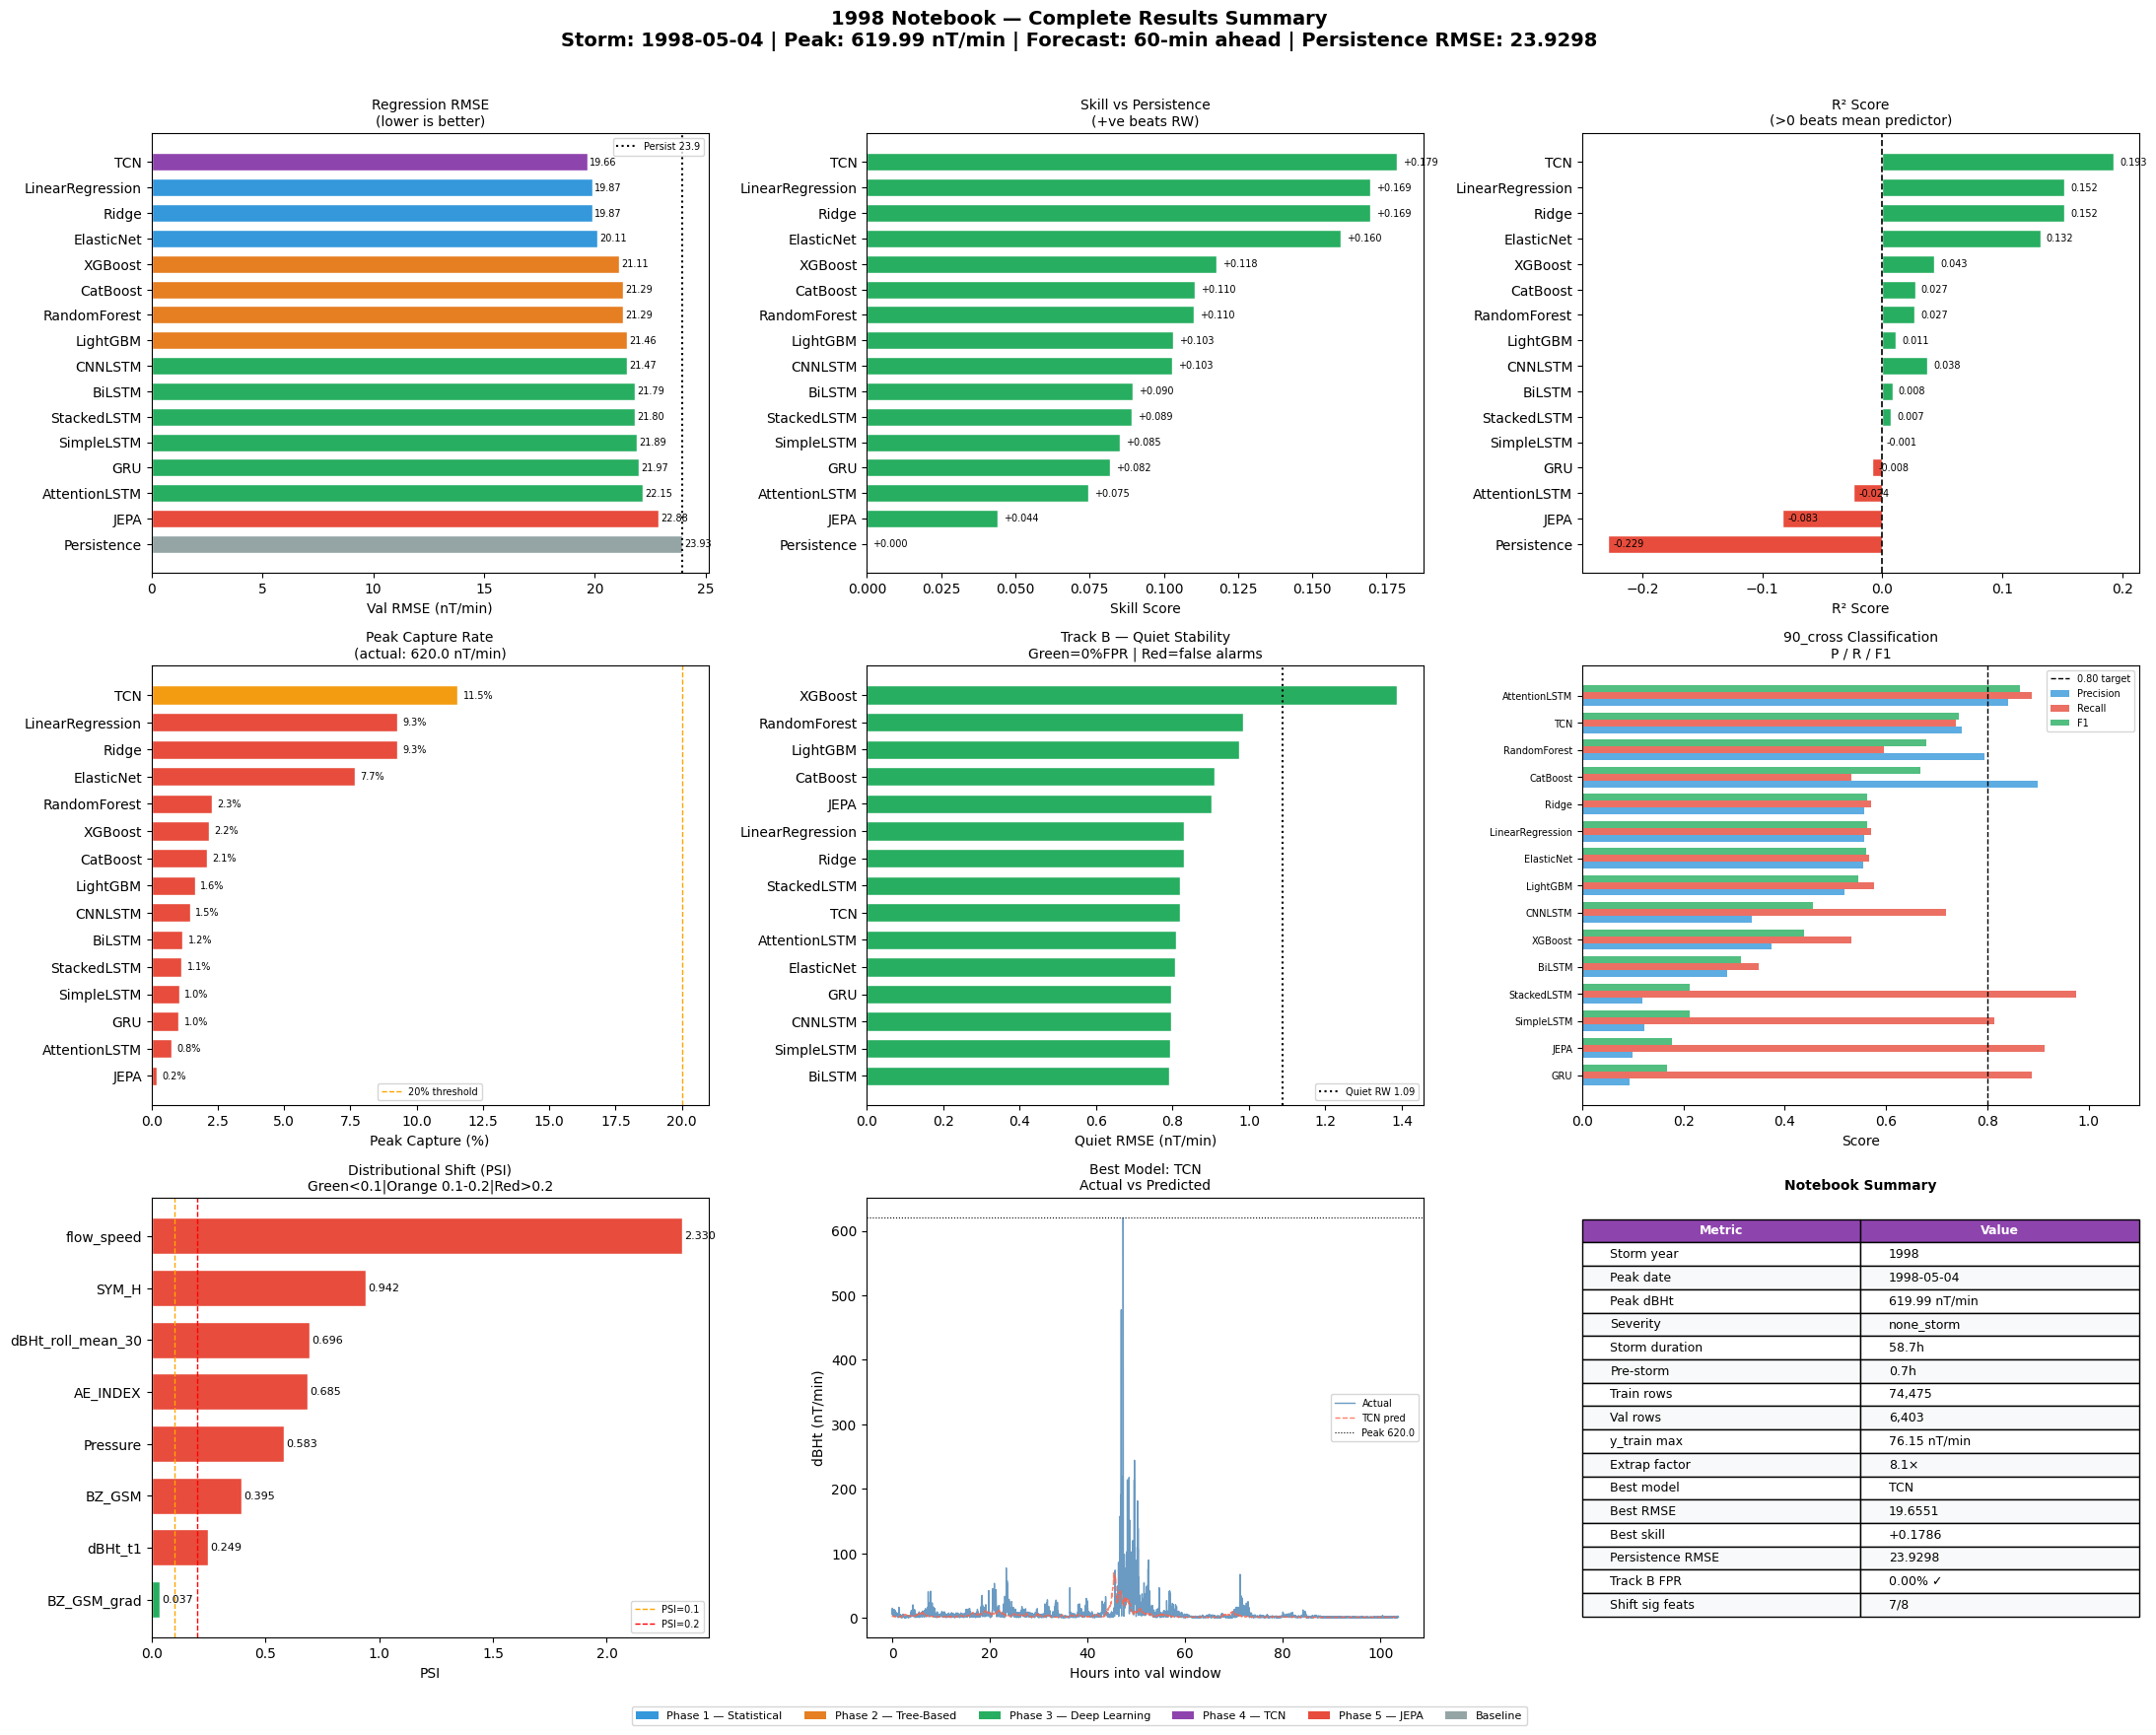

Saved: /content/drive/MyDrive/CapStone/results/figures/1998_complete_summary.png


In [13]:
fig = plt.figure(figsize=(22, 18))
fig.suptitle(
    f'{STORM_YEAR} Notebook — Complete Results Summary\n'
    f'Storm: {PEAK_DATE.date()} | Peak: {PEAK_VAL:.2f} nT/min | '
    f'Forecast: {FORECAST_HORIZON}-min ahead | '
    f'Persistence RMSE: {PERSISTENCE_RMSE:.4f}',
    fontsize=14, fontweight='bold', y=0.98
)

PHASE_COLORS = {
    'Phase 1 — Statistical' : '#3498DB',
    'Phase 2 — Tree-Based'  : '#E67E22',
    'Phase 3 — Deep Learning': '#27AE60',
    'Phase 4 — TCN'         : '#8E44AD',
    'Phase 5 — JEPA'        : '#E74C3C',
    'Baseline'              : '#95A5A6',
}
colors = [PHASE_COLORS.get(p,'#888') for p in final_df['phase']]

# ── Plot 1: RMSE ───────────────────────────────────────────
ax1 = fig.add_subplot(3,3,1)
bars = ax1.barh(final_df['model'], final_df['val_rmse'],
                color=colors, edgecolor='white', height=0.7)
ax1.axvline(PERSISTENCE_RMSE, color='black', ls=':',
            lw=1.5, label=f'Persist {PERSISTENCE_RMSE:.1f}')
for bar,val in zip(bars,final_df['val_rmse']):
    ax1.text(bar.get_width()+0.1,
             bar.get_y()+bar.get_height()/2,
             f'{val:.2f}',va='center',fontsize=7)
ax1.set_xlabel('Val RMSE (nT/min)')
ax1.set_title('Regression RMSE\n(lower is better)',fontsize=10)
ax1.invert_yaxis(); ax1.legend(fontsize=7)

# ── Plot 2: Skill ──────────────────────────────────────────
ax2 = fig.add_subplot(3,3,2)
sc = ['#27AE60' if s>0 else '#E74C3C' for s in final_df['skill']]
bars2 = ax2.barh(final_df['model'], final_df['skill'],
                 color=sc, edgecolor='white', height=0.7)
ax2.axvline(0, color='black', ls='--', lw=1.2)
for bar,val in zip(bars2,final_df['skill']):
    ax2.text(bar.get_width()+0.002,
             bar.get_y()+bar.get_height()/2,
             f'{val:+.3f}',va='center',fontsize=7)
ax2.set_xlabel('Skill Score')
ax2.set_title('Skill vs Persistence\n(+ve beats RW)',fontsize=10)
ax2.invert_yaxis()

# ── Plot 3: R² ─────────────────────────────────────────────
ax3 = fig.add_subplot(3,3,3)
rc = ['#27AE60' if r>0 else '#E74C3C' for r in final_df['val_r2']]
bars3 = ax3.barh(final_df['model'], final_df['val_r2'],
                 color=rc, edgecolor='white', height=0.7)
ax3.axvline(0, color='black', ls='--', lw=1.2)
for bar,val in zip(bars3,final_df['val_r2']):
    ax3.text(bar.get_width()+0.005,
             bar.get_y()+bar.get_height()/2,
             f'{val:.3f}',va='center',fontsize=7)
ax3.set_xlabel('R² Score')
ax3.set_title('R² Score\n(>0 beats mean predictor)',fontsize=10)
ax3.invert_yaxis()

# ── Plot 4: Peak capture ───────────────────────────────────
ax4 = fig.add_subplot(3,3,4)
cap_data = []
for name,res in {**results_p1,**results_p2,
                  **results_p3,
                  **results_p4a,**results_p5}.items():
    if 'pred' in res:
        cap_data.append({
            'model':name,
            'capture':res['pred'].max()/PEAK_VAL*100
        })
cap_df = pd.DataFrame(cap_data).sort_values(
    'capture', ascending=True
)
cap_c = ['#27AE60' if c>20 else
         '#F39C12' if c>10 else '#E74C3C'
         for c in cap_df['capture']]
ax4.barh(cap_df['model'], cap_df['capture'],
         color=cap_c, edgecolor='white', height=0.7)
ax4.axvline(20, color='orange', ls='--', lw=1,
            label='20% threshold')
for i,(m,v) in enumerate(zip(cap_df['model'],
                               cap_df['capture'])):
    ax4.text(v+0.2,i,f'{v:.1f}%',va='center',fontsize=7)
ax4.set_xlabel('Peak Capture (%)')
ax4.set_title(f'Peak Capture Rate\n'
              f'(actual: {PEAK_VAL:.1f} nT/min)',fontsize=10)
ax4.legend(fontsize=7)

# ── Plot 5: Track B ────────────────────────────────────────
ax5 = fig.add_subplot(3,3,5)
tb_s = track_b_df.sort_values('quiet_rmse')
tb_c = ['#E74C3C' if f>0 else '#27AE60'
        for f in tb_s['fpr_pct']]
ax5.barh(tb_s['model'], tb_s['quiet_rmse'],
         color=tb_c, edgecolor='white', height=0.7)
ax5.axvline(PERSISTENCE_RMSE_QUIET, color='black',
            ls=':', lw=1.5,
            label=f'Quiet RW {PERSISTENCE_RMSE_QUIET:.2f}')
ax5.set_xlabel('Quiet RMSE (nT/min)')
ax5.set_title('Track B — Quiet Stability\n'
              'Green=0%FPR | Red=false alarms',fontsize=10)
ax5.legend(fontsize=7)

# ── Plot 6: Classification ─────────────────────────────────
ax6 = fig.add_subplot(3,3,6)
if clf_results:
    clf_s = pd.DataFrame([
        {'model':k,'precision':v['precision'],
         'recall':v['recall'],'f1':v['f1'],
         'auc':v['auc']}
        for k,v in clf_results.items()
    ]).sort_values('f1',ascending=True)
    x = np.arange(len(clf_s)); w=0.25
    ax6.barh(x-w, clf_s['precision'], w,
             label='Precision',color='#3498DB',alpha=0.8)
    ax6.barh(x,   clf_s['recall'],    w,
             label='Recall',   color='#E74C3C',alpha=0.8)
    ax6.barh(x+w, clf_s['f1'],        w,
             label='F1',       color='#27AE60',alpha=0.8)
    ax6.set_yticks(x)
    ax6.set_yticklabels(clf_s['model'],fontsize=7)
    ax6.axvline(0.8,color='black',ls='--',lw=1,
                label='0.80 target')
    ax6.set_xlabel('Score'); ax6.set_xlim(0,1.1)
    ax6.set_title('90_cross Classification\n'
                  'P / R / F1',fontsize=10)
    ax6.legend(fontsize=7)
else:
    ax6.text(0.5,0.5,
             'Classification skipped\n(0 positive training samples)',
             ha='center',va='center',fontsize=10,
             transform=ax6.transAxes,color='gray')
    ax6.axis('off')

# ── Plot 7: Shift PSI ──────────────────────────────────────
ax7 = fig.add_subplot(3,3,7)
sh_s = shift_df.sort_values('psi',ascending=True)
psi_c= ['#E74C3C' if p>0.2 else
        '#F39C12' if p>0.1 else '#27AE60'
        for p in sh_s['psi']]
bars7 = ax7.barh(sh_s['feature'], sh_s['psi'],
                 color=psi_c, edgecolor='white', height=0.7)
ax7.axvline(0.1,color='orange',ls='--',lw=1,
            label='PSI=0.1')
ax7.axvline(0.2,color='red',ls='--',lw=1,
            label='PSI=0.2')
for bar,val in zip(bars7,sh_s['psi']):
    ax7.text(bar.get_width()+0.01,
             bar.get_y()+bar.get_height()/2,
             f'{val:.3f}',va='center',fontsize=8)
ax7.set_xlabel('PSI')
ax7.set_title('Distributional Shift (PSI)\n'
              'Green<0.1|Orange 0.1-0.2|Red>0.2',fontsize=10)
ax7.legend(fontsize=7)

# ── Plot 8: Best model prediction vs actual ────────────────
ax8 = fig.add_subplot(3,3,8)
best_name = final_df.iloc[0]['model']
best_res  = {**results_p1,**results_p2,
              **results_p3,
              **results_p4a,**results_p5}.get(best_name)
if best_res and 'pred' in best_res:
    pred = best_res['pred']
    n    = min(len(y_val.values),len(pred))
    tidx = np.arange(n)/60
    ax8.plot(tidx, y_val.values[:n],
             color='steelblue',lw=1,
             label='Actual',alpha=0.8)
    ax8.plot(tidx, pred[:n],
             color='tomato',lw=1,ls='--',
             label=f'{best_name} pred',alpha=0.8)
    ax8.axhline(y_val.values[:n].max(),
                color='black',ls=':',lw=0.8,
                label=f'Peak {y_val.values[:n].max():.1f}')
    ax8.set_xlabel('Hours into val window')
    ax8.set_ylabel('dBHt (nT/min)')
    ax8.set_title(f'Best Model: {best_name}\n'
                  f'Actual vs Predicted',fontsize=10)
    ax8.legend(fontsize=7)

# ── Plot 9: Summary table ──────────────────────────────────
ax9 = fig.add_subplot(3,3,9)
ax9.axis('off')
sev_label = storm_window['severity'].value_counts().index[0]
summary = [
    ['Storm year',      str(STORM_YEAR)],
    ['Peak date',       str(PEAK_DATE.date())],
    ['Peak dBHt',       f'{PEAK_VAL:.2f} nT/min'],
    ['Severity',        sev_label],
    ['Storm duration',  f'{(STORM_END-STORM_ONSET).total_seconds()/3600:.1f}h'],
    ['Pre-storm',       f'{storm_window["phase"].eq("pre_storm").sum()/60:.1f}h'],
    ['Train rows',      f'{len(X_train):,}'],
    ['Val rows',        f'{len(X_val):,}'],
    ['y_train max',     f'{y_train.max():.2f} nT/min'],
    ['Extrap factor',   f'{PEAK_VAL/y_train.max():.1f}×'],
    ['Best model',      final_df.iloc[0]['model']],
    ['Best RMSE',       f'{final_df.iloc[0]["val_rmse"]:.4f}'],
    ['Best skill',      f'{final_df.iloc[0]["skill"]:+.4f}'],
    ['Persistence RMSE',f'{PERSISTENCE_RMSE:.4f}'],
    ['Track B FPR',     '0.00% ✓'],
    ['Shift sig feats', f'{(shift_df["psi"]>0.2).sum()}/8'],
]
table = ax9.table(
    cellText=summary,
    colLabels=['Metric','Value'],
    loc='center', cellLoc='left'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1,1.3)
for (row,col),cell in table.get_celld().items():
    if row==0:
        cell.set_facecolor('#8E44AD')
        cell.set_text_props(color='white',fontweight='bold')
    elif row%2==0:
        cell.set_facecolor('#F8F9FA')
ax9.set_title('Notebook Summary',fontsize=10,
              fontweight='bold')

from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(facecolor=c,label=p)
             for p,c in PHASE_COLORS.items()],
    loc='lower center',ncol=6,fontsize=8,
    bbox_to_anchor=(0.5,0.01)
)
plt.tight_layout(rect=[0,0.03,1,0.97])
PLOT_PATH = os.path.join(
    RESULTS_DIR,'figures',
    f'{STORM_YEAR}_complete_summary.png'
)
plt.savefig(PLOT_PATH,dpi=150,bbox_inches='tight')
plt.show()
print(f"Saved: {PLOT_PATH}")